In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv('../data/Train.csv')
print("Dataset Shape:", df.shape)
df.head()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1000, 12)

Missing Values:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [5]:
X = df.drop("Reached.on.Time_Y.N", axis=1)
y = df["Reached.on.Time_Y.N"]
X = pd.get_dummies(X, drop_first=True)

selector = SelectKBest(score_func=f_classif, k=2)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Weight_in_gms', 'Product_importance_medium'], dtype='object')


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

pca = PCA(n_components=2)
S = pca.fit_transform(X_scaled)

print("Original Shape (Selected):", X_scaled.shape)
print("PCA Shape:", S.shape)

Original Shape (Selected): (1000, 2)
PCA Shape: (1000, 2)


In [7]:
rf = RandomForestClassifier(random_state=42)
rf.fit(S, y)

print("Model Trained Successfully")
importance = rf.feature_importances_
print("Feature Importance of PCA Components:", importance)

Model Trained Successfully
Feature Importance of PCA Components: [0.49944288 0.50055712]


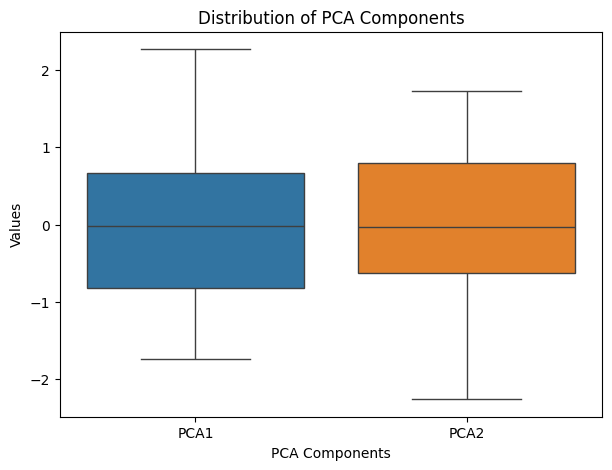

In [8]:
pca_df = pd.DataFrame(S, columns=["PCA1","PCA2"])

plt.figure(figsize=(7,5))
sns.boxplot(data=pca_df)

plt.title("Distribution of PCA Components")
plt.xlabel("PCA Components")
plt.ylabel("Values")
plt.show()